In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("earthquake_1995-2023.csv")

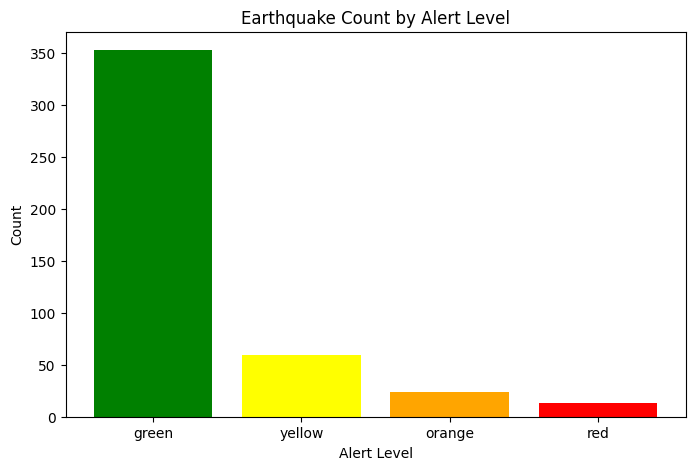

In [2]:
alert_counts = df["alert"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(
    alert_counts.index,
    alert_counts.values,
    color=["green", "yellow", "orange", "red"],
)
plt.title("Earthquake Count by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Count")
plt.show()

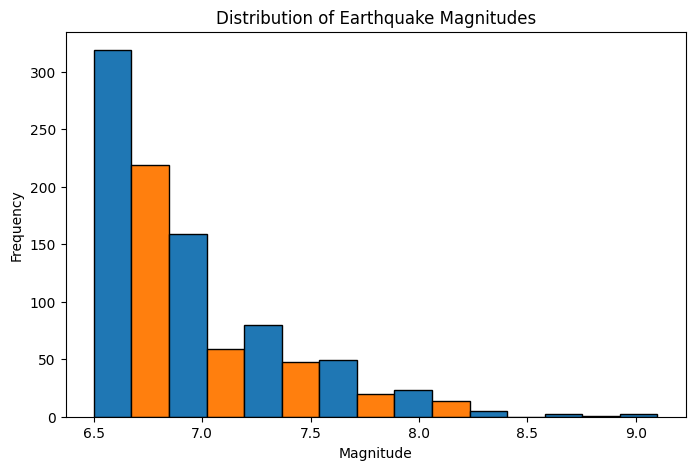

In [3]:
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(
    df["magnitude"].dropna(), bins=15, edgecolor="black"
)
colors = ["#1f77b4", "#ff7f0e"]  # Blue and Orange
for i, patch in enumerate(patches):
    patch.set_facecolor(colors[i % 2])  # Alternate colors

plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

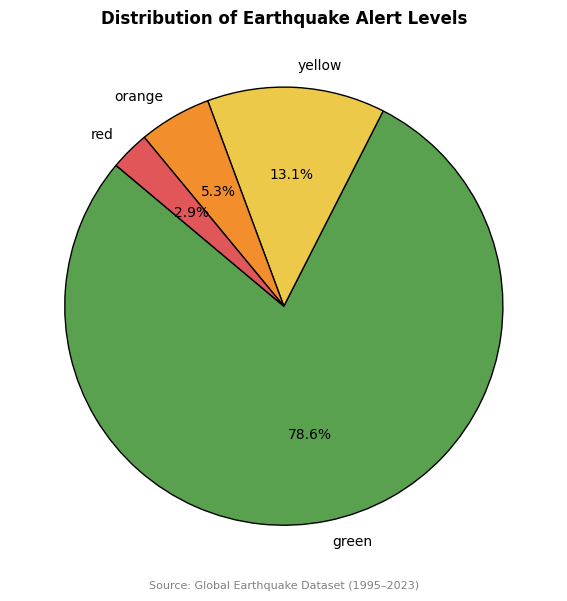

In [8]:
# Get alert value counts
alert_counts = df["alert"].dropna().value_counts()

# Color mapping
colors = {
    "green": "#59a14f",
    "yellow": "#edc949",
    "orange": "#f28e2b",
    "red": "#e15759",
}
pie_colors = [colors.get(c, "#76b7b2") for c in alert_counts.index]

# Plot Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    alert_counts.values,
    labels=alert_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    wedgeprops={"edgecolor": "black", "linewidth": 1},
)

ax.set_title("Distribution of Earthquake Alert Levels", fontweight="bold")
fig.text(
    0.5,
    0.01,
    "Source: Global Earthquake Dataset (1995–2023)",
    ha="center",
    fontsize=8,
    color="gray",
)

plt.tight_layout()
plt.show()

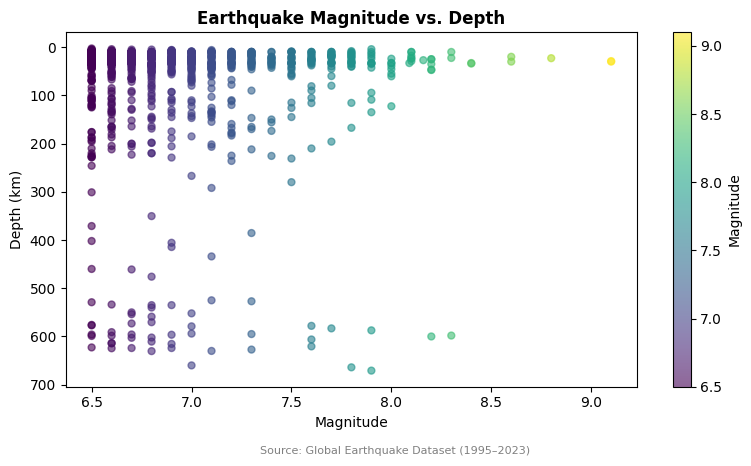

In [10]:
# Plot Scatter Plot: Magnitude vs. Depth
fig, ax = plt.subplots(figsize=(8, 4.5))
scatter = ax.scatter(
    df["magnitude"],
    df["depth"],
    c=df["magnitude"],
    cmap="viridis",
    alpha=0.6,
    s=25,
)

ax.set_title("Earthquake Magnitude vs. Depth", fontweight="bold")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Depth (km)")
ax.invert_yaxis()  # Invert so deeper events plot further down

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Magnitude")

fig.text(
    0.5,
    -0.02,
    "Source: Global Earthquake Dataset (1995–2023)",
    ha="center",
    fontsize=8,
    color="gray",
)

plt.tight_layout()
plt.show()

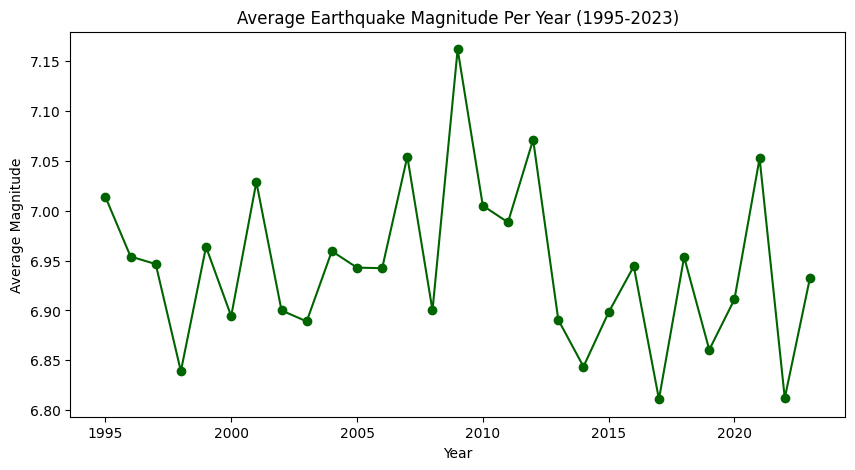

In [11]:
df["year"] = pd.to_datetime(
    df["date_time"], format="mixed", dayfirst=True, errors="coerce"
).dt.year

yearly_mag = df.groupby("year")["magnitude"].mean()

plt.figure(figsize=(10, 5))
plt.plot(
    yearly_mag.index,
    yearly_mag.values,
    marker="o",
    linestyle="-",
    color="darkgreen",
)
plt.title("Average Earthquake Magnitude Per Year (1995-2023)")
plt.xlabel("Year")
plt.ylabel("Average Magnitude")
plt.show()